In [1]:
import pandas as pd

from benchmarking.metrics.base_metrics import (
    compute_precision_recall_data,
    load_all_feature_tables,
    compute_r2_values_for_plant_spikein,
)
from benchmarking.loader import get_confident_tps
from benchmarking.plots import (
    plot_specific_pr_curves,
    plot_true_positive_overlap,
    plot_transform_combinations_lineplot,
    plot_r2_distribution,
)

import matplotlib.pyplot as plt

# Load in data

In [2]:
plant_spikein_library_data = pd.read_parquet(
    "../data/library_spectra/plant_spikein_lib.pq"
)
plant_spikein_library_data.head(2)

,normalized_mzs,normalized_intensities,precursor_mz,inchikey_2d,metabolite_name
0,"[41.039039611816406,43.05400085449219,53.55109...","[3351.0,5322.0,868.0,6639.0,745.0,5202.0,569.0...",379.214996,AIULWNKTYPZYAN-SFHVURJKSA-N,10-gingerol
1,"[57.06970977783203,124.9695816040039,129.06988...","[1255.0,421.0,761.0,478.0,118.0,388.0,464.0,62...",315.157144,AIULWNKTYPZYAN-SFHVURJKSA-N,10-gingerol


In [3]:
plant_spikein_library_data["inchikey_2d"].nunique()

39

In [4]:
# Building the feature table for reframe_spikein_dataset
merged_feature_tables = load_all_feature_tables(
    ["../data/groundtruth_dataset/plant_spikein"],
    annotation_subfolder="annotated_spectral_entropy",
)

100%|██████████| 1/1 [00:00<00:00,  5.28it/s]


# Compounds overlapping acorss tools

In [5]:
confident_tps = get_confident_tps(
    merged_feature_tables=merged_feature_tables,
    ground_truth_library_data=plant_spikein_library_data,
    spectral_score_threshold=0.7,
)

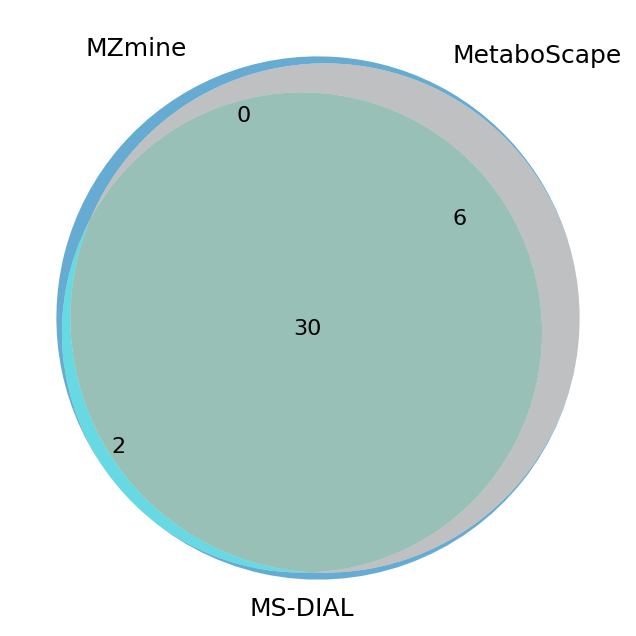

In [6]:
plot_true_positive_overlap(
    tool_inchikeys=confident_tps,
    title=None,
    figsize=(8, 8),
)

# Plot recall curve

In [7]:
score_range, precision_recall_curves, confusion_matrix_data = (
    compute_precision_recall_data(
        merged_feature_tables=merged_feature_tables,
        ground_truth_data=plant_spikein_library_data,
        score_threshold=0.7,
    )
)

Number of unique true InChIKeys (14-character): 39


# Concentration dependent plot

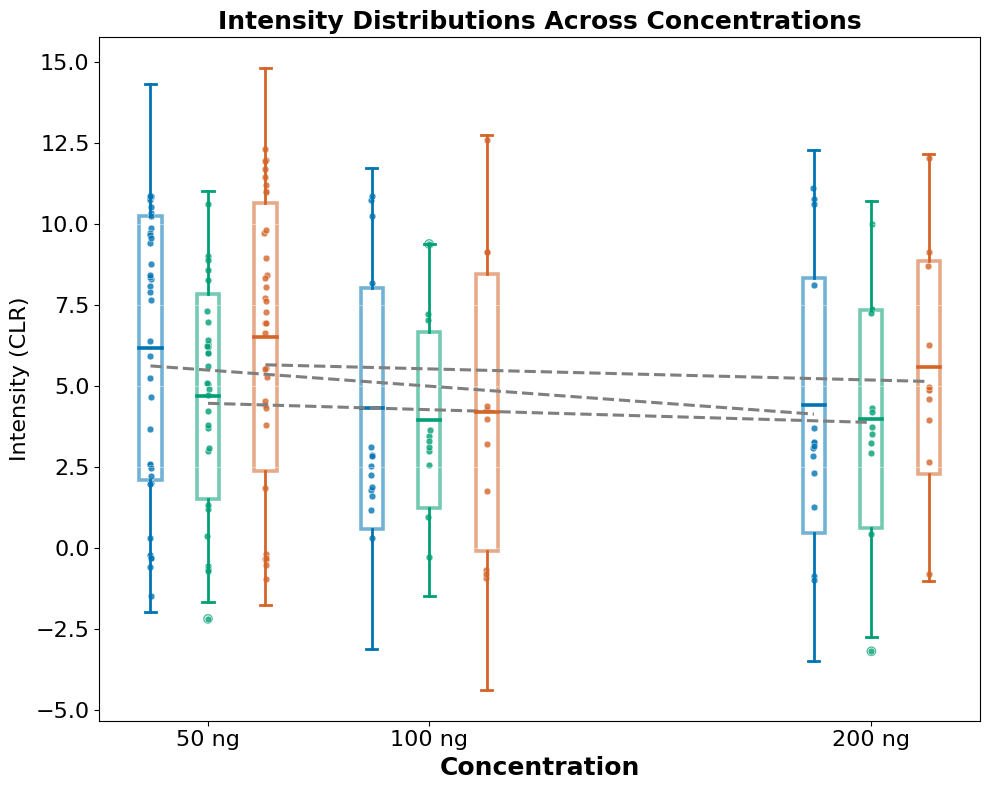

In [8]:
plot_transform_combinations_lineplot(
    merged_feature_tables,
    ground_truth_data_combined=plant_spikein_library_data,
    combinations=[("mzmine", "clr"), ("msdial", "clr"), ("metaboscape", "clr")],
    log_base_x=None,
    log_base_y=None,
    hist_width=5,
    figsize=(10, 8),
    # save_path="../figures/figure_5b.png",
)

In [9]:
r2_values = compute_r2_values_for_plant_spikein(
    merged_feature_tables=merged_feature_tables,
    groundtruth_data=plant_spikein_library_data,
    combinations=[("mzmine", "clr"), ("msdial", "clr"), ("metaboscape", "clr")],
    concentrations={50, 100, 200},
    score_threshold=0.7,
)

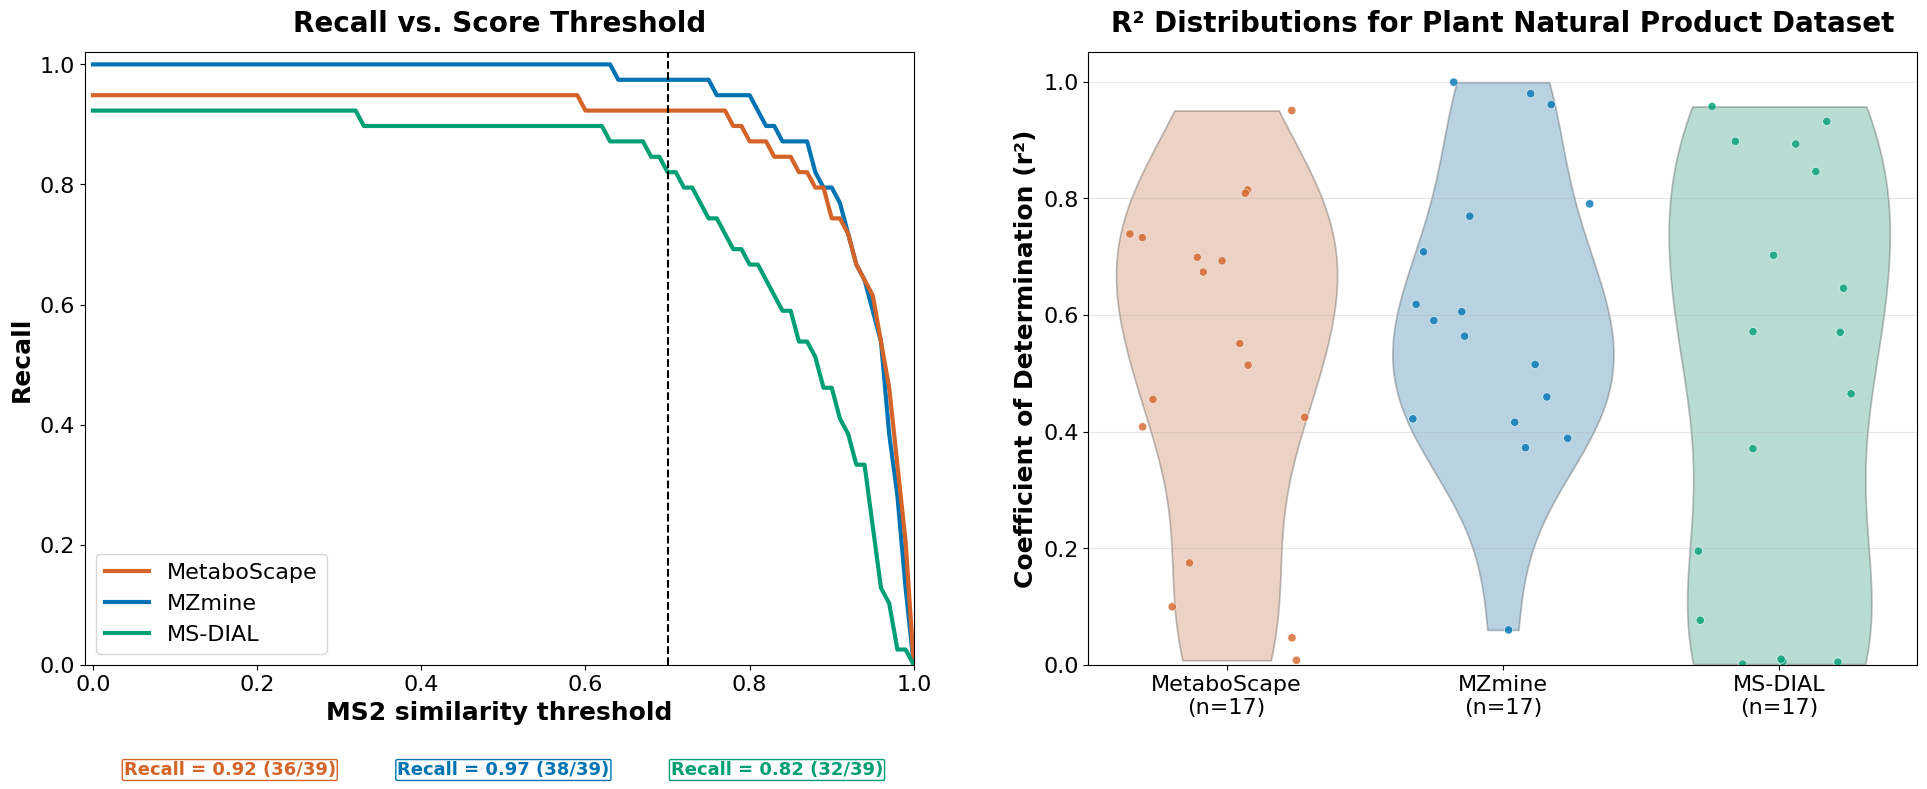

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

plot_specific_pr_curves(
    score_range,
    precision_recall_curves,
    confusion_matrix_data,
    x_var="score",
    y_var="recall",
    confusion_matrix_threshold=0.7,
    title="Recall vs. Score Threshold",
    fig_size=(10, 8),
    ax=axes[0],
)

plot_r2_distribution(
    r2_values,
    significant_only=False,
    significance_threshold=0.05,
    title="R² Distributions for Plant Natural Product Dataset",
    figsize=(10, 8),
    ax=axes[1],
)

# add spacing between subplots and save the combined figure
fig.subplots_adjust(wspace=10)

plt.tight_layout()
plt.savefig("../figures/figure_5.png", dpi=400, bbox_inches="tight")
plt.show()